In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

C:\Users\pavan\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv("IPL_Auction_Player_Performance_Analytics.csv")
print(df.shape)
df.head()

(12000, 13)


,Name,Age,Country,Role,Matches,Experience ( in Yrs),Runs,Strike_Rate,Wickets,Economy,Average,Team_Preference,Auction_Price ( in Cr )
0,MS Dhoni,42,India,Wicketkeeper,350,20,12000,135.0,0,0.00,50.00,CSK,20.0
1,Sachin Tendulkar,45,India,Batter,400,24,18000,125.0,5,8.50,45.00,MI,1.5
2,Virat Kohli,36,India,Batter,300,16,13000,138.0,2,7.00,52.00,RCB,18.0
3,Rohit Sharma,37,India,Batter,280,17,14000,132.0,0,8.00,48.00,MI,18.0
4,Jasprit Bumrah,35,India,Bowler,196,7,2661,144.9,798,7.69,27.43,MI,12.0


## Simulated Auction Price (Target with a Real Signal)

- The original `Auction_Price` column has no real relationship with the stats, so this section builds a **simulated price target** instead.
- **Batting output** (Runs, Strike Rate, Average) drives price for Batters and Wicketkeepers.
- **Bowling output** (Wickets, Economy) drives price for Bowlers.
- **Allrounders** get a mix of both batting and bowling output, plus a flat bonus.
- **Experience** (years played, matches) adds further weight to price.
- **Country** adds a premium — Indian players get a bigger boost, reflecting real IPL demand patterns.
- A small amount of **random noise** is added so the price isn't perfectly deterministic, keeping it more realistic.

In [3]:
np.random.seed(42)

batting_score = (df["Runs"] / 1000) * 0.6 + (df["Strike_Rate"] - 100) * 0.04 + df["Average"] * 0.05
bowling_score = (df["Wickets"] / 50) * 0.6 + (9.5 - df["Economy"]) * 0.5

role_weight_bat = df["Role"].map({"Batter": 1.0, "Wicketkeeper": 0.9, "Allrounder": 0.6, "Bowler": 0.15})
role_weight_bowl = df["Role"].map({"Batter": 0.1, "Wicketkeeper": 0.1, "Allrounder": 0.6, "Bowler": 1.0})

skill_score = batting_score * role_weight_bat + bowling_score * role_weight_bowl
allround_bonus = np.where(df["Role"] == "Allrounder", 1.5, 0)
keeper_bonus = np.where(df["Role"] == "Wicketkeeper", 0.5, 0)
experience_score = df["Experience ( in Yrs)"] * 0.12 + df["Matches"] * 0.01
age_penalty = -np.abs(df["Age"] - 28) * 0.06
country_bonus = np.where(df["Country"] == "India", 1.8, 0.4)
noise = np.random.normal(0, 1.2, size=len(df))

sim_price = 1.0 + skill_score + allround_bonus + keeper_bonus + experience_score + age_penalty + country_bonus + noise
sim_price = sim_price.clip(lower=0.2, upper=20)

df["Auction_Price_Simulated ( in Cr )"] = sim_price.round(2)
df[["Name", "Role", "Country", "Auction_Price ( in Cr )", "Auction_Price_Simulated ( in Cr )"]].head(10)

,Name,Role,Country,Auction_Price ( in Cr ),Auction_Price_Simulated ( in Cr )
0,MS Dhoni,Wicketkeeper,India,20.0,19.42
1,Sachin Tendulkar,Batter,India,1.5,20.00
2,Virat Kohli,Batter,India,18.0,20.00
3,Rohit Sharma,Batter,India,18.0,20.00
4,Jasprit Bumrah,Bowler,India,12.0,16.09
5,Rahul Dravid,Batter,India,5.0,14.58
6,Sourav Ganguly,Batter,India,3.0,12.08
7,Anil Kumble,Bowler,India,0.5,11.40
8,Kapil Dev,Allrounder,India,0.5,9.07
9,Sunil Gavaskar,Batter,India,0.2,12.22


In [4]:
df=df.drop(columns=["Auction_Price ( in Cr )"])

In [5]:
df.head()

,Name,Age,Country,Role,Matches,Experience ( in Yrs),Runs,Strike_Rate,Wickets,Economy,Average,Team_Preference,Auction_Price_Simulated ( in Cr )
0,MS Dhoni,42,India,Wicketkeeper,350,20,12000,135.0,0,0.00,50.00,CSK,19.42
1,Sachin Tendulkar,45,India,Batter,400,24,18000,125.0,5,8.50,45.00,MI,20.00
2,Virat Kohli,36,India,Batter,300,16,13000,138.0,2,7.00,52.00,RCB,20.00
3,Rohit Sharma,37,India,Batter,280,17,14000,132.0,0,8.00,48.00,MI,20.00
4,Jasprit Bumrah,35,India,Bowler,196,7,2661,144.9,798,7.69,27.43,MI,16.09


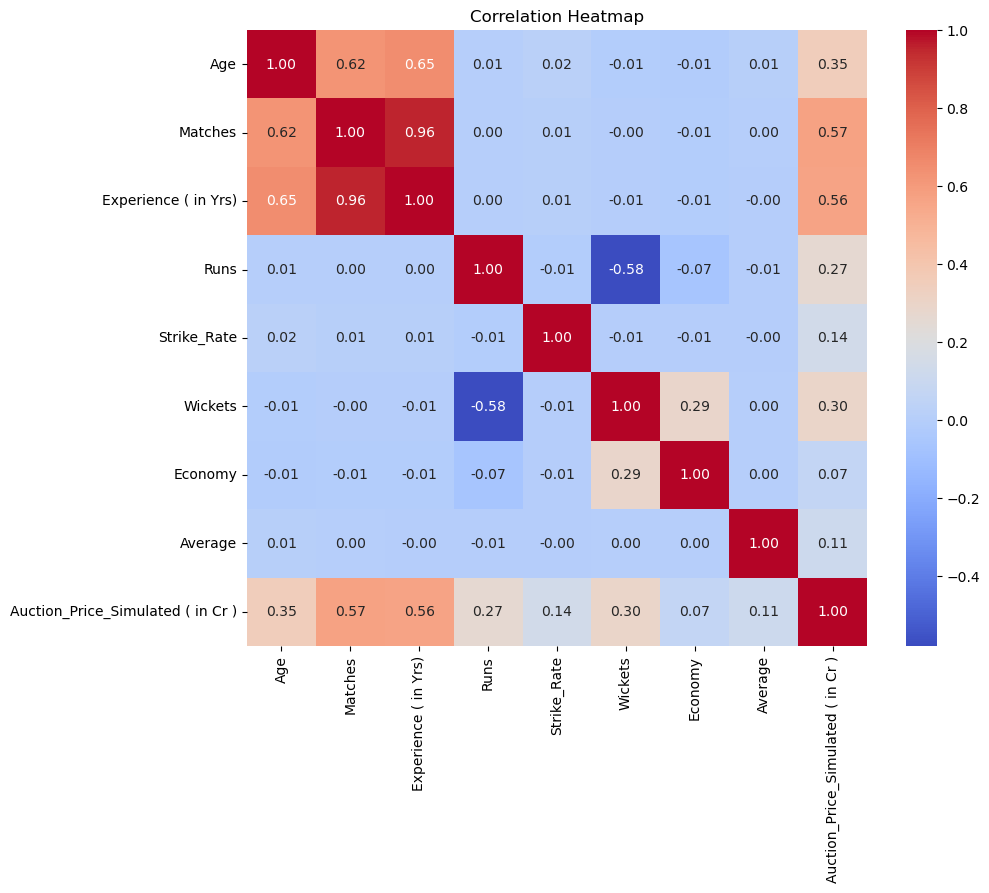

In [6]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

1. **Avoids misleading correlations** — irrelevant stats (e.g. a bowler's Strike Rate) don't affect price.
2. **Mirrors real auctions** — batters priced on batting, bowlers on bowling, like actual franchises evaluate.
3. **Values Allrounders higher** — even weighting on both skills naturally reflects their real premium.

In [8]:
df.to_csv("Modified_dataset")